<a href="https://colab.research.google.com/github/hariali-tech/NLP_assignment/blob/main/NLP_assign2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving train.csv to train.csv
Uploaded: ['train.csv']


In [ ]:
import pandas as pd
import numpy as np

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy.sparse import hstack

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

print("All libraries ready!")

All libraries ready!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
df = pd.read_csv('train.csv', encoding='latin-1')

df = df[['text', 'sentiment']].dropna()

print("Dataset Shape:", df.shape)
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

print("\nFirst 5 rows:")
df.head()

Dataset Shape: (27480, 2)

Sentiment Distribution:
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

First 5 rows:


,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


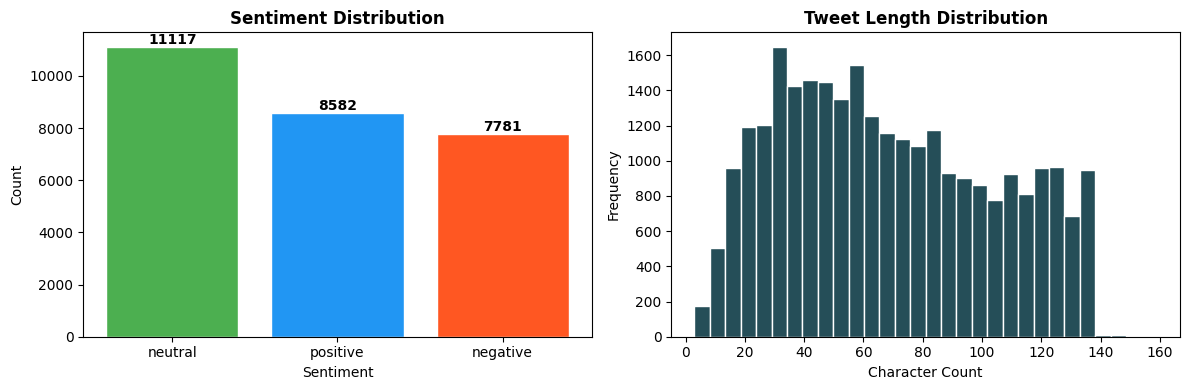


Average tweet length: 68.4 characters


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#4CAF50', '#2196F3', '#FF5722'], edgecolor='white')
axes[0].set_title('Sentiment Distribution', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 100, str(val), ha='center', fontweight='bold')

df['text_length'] = df['text'].astype(str).apply(len)
axes[1].hist(df['text_length'], bins=30, color='#254E58', edgecolor='white')
axes[1].set_title('Tweet Length Distribution', fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"\nAverage tweet length: {df['text_length'].mean():.1f} characters")

In [ ]:
USE_SUBSET = True
SUBSET_SIZE = 5000

if USE_SUBSET:
    df = (
        df.groupby('sentiment', group_keys=False)
          .apply(lambda x: x.sample(min(len(x), SUBSET_SIZE), random_state=42))
          .reset_index(drop=True)
    )
    print(f"Using balanced subset — {df.shape[0]} rows")
    print(df['sentiment'].value_counts())
else:
    print(f"Using full dataset — {df.shape[0]} rows")

Using balanced subset — 15000 rows
sentiment
negative    5000
neutral     5000
positive    5000
Name: count, dtype: int64


/tmp/ipykernel_19014/2249326135.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), SUBSET_SIZE), random_state=42))


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full preprocessing pipeline for tweet text.
    """
    text = str(text)

    text = re.sub(r'http\S+|www\.\S+', '', text)

    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    text = text.lower()

    text = re.sub(r'[^a-z0-9\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

print("Preprocessing tweets... (this may take ~1 minute)")
df['cleaned_text'] = df['text'].apply(preprocess_text)
print(" Done!")

# Show before vs after
df[['text', 'cleaned_text', 'sentiment']].head(8)

Preprocessing tweets... (this may take ~1 minute)
 Done!


,text,cleaned_text,sentiment
0,says BAD TRIP! (angry) http://plurk.com/p/wxshi,say bad trip angry,negative
1,that sounds foreboding...,sound foreboding,negative
2,_kat I`ve begged my mum to lt me get them out...,kat ive begged mum lt get attic wont let waaa ...,negative
3,"is really, really bored... I guess I will go t...",really really bored guess go bed,negative
4,I just stuck my finger down my throat and ther...,stuck finger throat bunch bump tongue throat,negative
5,pictures of your bliss? In JPEG format? Sor...,picture bliss jpeg format sorry message board ...,negative
6,My teratoma has a cavity and is experiencing m...,teratoma cavity experiencing malepattern baldness,negative
7,First ever dropped call on my mobile. On a cal...,first ever dropped call mobile call less charg...,negative


In [ ]:
bow_vectorizer = CountVectorizer(
    token_pattern=r'(?u)\b\w\w+\b',
    ngram_range=(1, 1),
    analyzer='word',
    max_features=5000
)

X_bow = bow_vectorizer.fit_transform(df['cleaned_text'])
print("BoW matrix shape:", X_bow.shape)

bow_df_sample = pd.DataFrame(
    X_bow[:5].toarray(),
    columns=bow_vectorizer.get_feature_names_out()
).iloc[:, :10]
print("\nBag of Words (sample — first 10 features):")
bow_df_sample

BoW matrix shape: (15000, 5000)

Bag of Words (sample — first 10 features):


,01,08,09,10,100,1000,10000,101,1015,1030
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r'(?u)\b\w\w+\b',
    ngram_range=(1, 1),
    analyzer='word',
    max_features=5000
)

X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_text'])
print("TF-IDF matrix shape:", X_tfidf.shape)

tfidf_df_sample = pd.DataFrame(
    X_tfidf[:5].toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
).iloc[:, :10]
print("\nTF-IDF (sample — first 10 features):")
tfidf_df_sample

TF-IDF matrix shape: (15000, 5000)

TF-IDF (sample — first 10 features):


,01,08,09,10,100,1000,10000,101,1015,1030
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_combined = hstack([X_bow, X_tfidf])
print("Combined matrix shape:", X_combined.shape)

combined_names = (
    ['bow_' + f for f in bow_vectorizer.get_feature_names_out()] +
    ['tfidf_' + f for f in tfidf_vectorizer.get_feature_names_out()]
)

combined_df_sample = pd.DataFrame(
    X_combined[:5].toarray(),
    columns=combined_names
).iloc[:, :10]
print("\nCombined Features (sample — first 10 features):")
combined_df_sample

Combined matrix shape: (15000, 10000)

Combined Features (sample — first 10 features):


,bow_01,bow_08,bow_09,bow_10,bow_100,bow_1000,bow_10000,bow_101,bow_1015,bow_1030
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

split_summary = pd.DataFrame({
    'Split'    : ['Train', 'Test'],
    'Samples'  : [X_train.shape[0], X_test.shape[0]],
    'Positive' : [sum(y_train == 'positive'), sum(y_test == 'positive')],
    'Negative' : [sum(y_train == 'negative'), sum(y_test == 'negative')],
    'Neutral'  : [sum(y_train == 'neutral'),  sum(y_test == 'neutral')],
})
print("Data Split Summary:")
split_summary

Data Split Summary:


,Split,Samples,Positive,Negative,Neutral
0,Train,12000,4000,4000,4000
1,Test,3000,1000,1000,1000


In [ ]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest trained!")

# ── 5.2  SVM ─────────────────────────────────────────────────────────────────
print("Training SVM...")
svm_model = LinearSVC(random_state=42, max_iter=2000)
svm_model.fit(X_train, y_train)
print("SVM trained!")

# ── 5.3  Naïve Bayes ─────────────────────────────────────────────────────────
print("Training Naïve Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
print("Naïve Bayes trained!")

Training Random Forest...
Random Forest trained!
Training SVM...
SVM trained!
Training Naïve Bayes...
Naïve Bayes trained!



  Model: Random Forest
  Accuracy  : 0.6823
  Precision : 0.6868
  Recall    : 0.6823
  F1-Score  : 0.6834


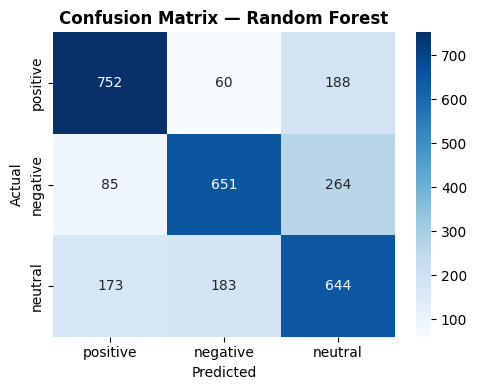


  Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.65      0.69      1000
     neutral       0.59      0.64      0.61      1000
    positive       0.74      0.75      0.75      1000

    accuracy                           0.68      3000
   macro avg       0.69      0.68      0.68      3000
weighted avg       0.69      0.68      0.68      3000


  Model: SVM
  Accuracy  : 0.6340
  Precision : 0.6351
  Recall    : 0.6340
  F1-Score  : 0.6344


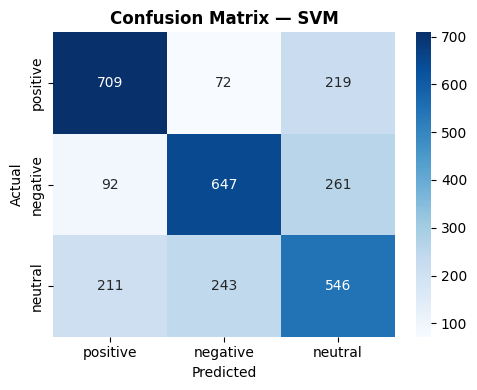


  Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.65      0.66      1000
     neutral       0.53      0.55      0.54      1000
    positive       0.70      0.71      0.70      1000

    accuracy                           0.63      3000
   macro avg       0.64      0.63      0.63      3000
weighted avg       0.64      0.63      0.63      3000


  Model: Naive Bayes
  Accuracy  : 0.6270
  Precision : 0.6219
  Recall    : 0.6270
  F1-Score  : 0.6237


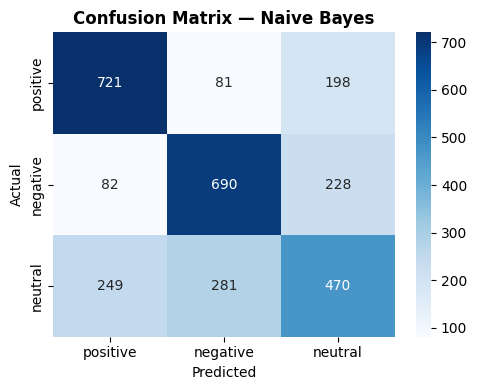


  Classification Report:
              precision    recall  f1-score   support

    negative       0.66      0.69      0.67      1000
     neutral       0.52      0.47      0.50      1000
    positive       0.69      0.72      0.70      1000

    accuracy                           0.63      3000
   macro avg       0.62      0.63      0.62      3000
weighted avg       0.62      0.63      0.62      3000



In [ ]:
def evaluate_model(name, model, X_test, y_test):
    """Print full evaluation and return metrics dict."""
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_test, y_pred, labels=['positive','negative','neutral'])
    cr   = classification_report(y_test, y_pred, zero_division=0)

    print(f"\n{'='*60}")
    print(f"  Model: {name}")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")

    # Confusion Matrix heatmap
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['positive','negative','neutral'],
        yticklabels=['positive','negative','neutral'],
        ax=ax
    )
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    print(f"\n  Classification Report:")
    print(cr)

    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}


results = []
results.append(evaluate_model('Random Forest', rf_model,  X_test, y_test))
results.append(evaluate_model('SVM',           svm_model, X_test, y_test))
results.append(evaluate_model('Naive Bayes',   nb_model,  X_test, y_test))

In [ ]:
results_df = pd.DataFrame(results).set_index('Model')
print("\n📋 All Models — Summary Table")
results_df.round(4)


📋 All Models — Summary Table


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,0.6823,0.6868,0.6823,0.6834
SVM,0.6340,0.6351,0.6340,0.6344
Naive Bayes,0.6270,0.6219,0.6270,0.6237


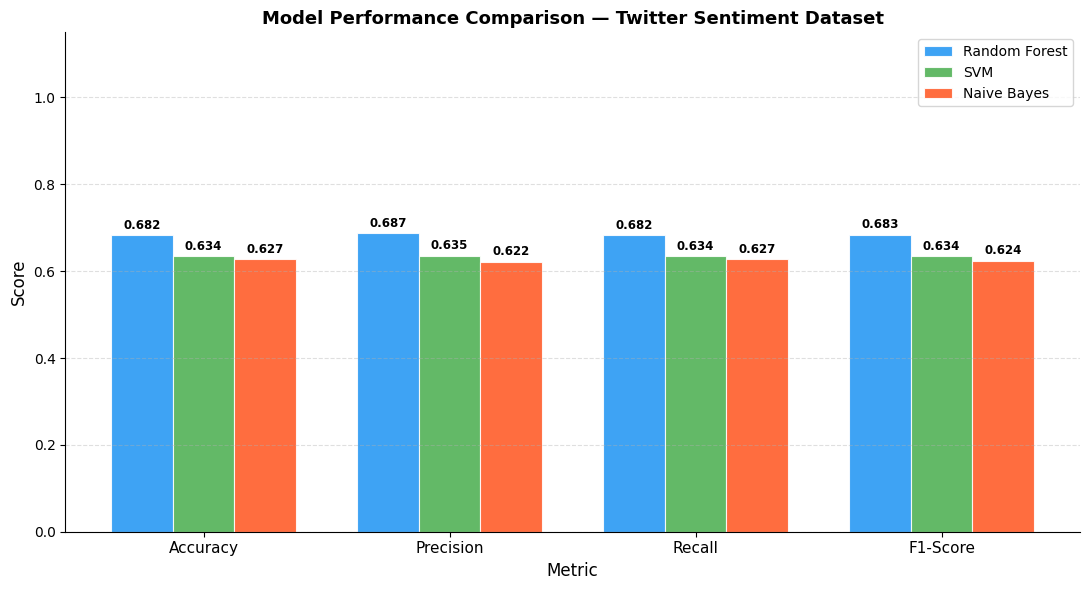

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models  = results_df.index.tolist()
colors  = ['#2196F3', '#4CAF50', '#FF5722']

x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    values = results_df.loc[model, metrics].values
    bars = ax.bar(x + i * width, values, width,
                  label=model, color=color, alpha=0.87, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold'
        )

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Twitter Sentiment Dataset',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()